# 07 — Comparación de Modelos y Análisis Crítico

**Proyecto:** Segmentación de células e interpretación de texto mediante modelos de deep learning  
**Sección:** Bloque 2 — NLP  
**Autor:** Dr. Lihki Rubio

Este notebook centraliza los resultados de los cinco modelos entrenados, genera la tabla comparativa oficial, produce visualizaciones de rendimiento y desarrolla el análisis crítico requerido por el proyecto.

**Modelos evaluados:**
| # | Notebook fuente | Modelo |
|---|---|---|
| 1 | `02_Model_TFIDF_XGBoost.ipynb` | TF-IDF + XGBoost |
| 2 | `03_Model_CNN1D.ipynb` | CNN-1D |
| 3 | `04_Model_BiLSTM.ipynb` | Word2Vec + BiLSTM |
| 4 | `05_Model_FastText.ipynb` | FastText |
| 5 | `06_Model_DistilBERT.ipynb` | DistilBERT fine-tuned |

**Fuente de datos:** archivos JSON en `artifacts/metrics/` generados por cada notebook.

## 0. Imports y configuración

In [1]:
import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Rutas
BASE_DIR     = Path(os.path.abspath(os.path.join(os.getcwd(), '..')))
METRICS_DIR  = BASE_DIR / 'artifacts' / 'metrics'

print(f'BASE_DIR    : {BASE_DIR}')
print(f'METRICS_DIR : {METRICS_DIR}')
assert METRICS_DIR.exists(), f'No existe {METRICS_DIR}'

# Estilo global
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

print('Imports OK')

BASE_DIR    : /home/alejo/DeepLearning/miniproyecto3
METRICS_DIR : /home/alejo/DeepLearning/miniproyecto3/artifacts/metrics
Imports OK


## 1. Carga de métricas

Cada notebook de modelado guardó un archivo JSON en `artifacts/metrics/` con la estructura estándar del proyecto. Aquí los cargamos todos y construimos un DataFrame unificado.

In [12]:
# Archivos esperados — orden para la tabla comparativa
METRIC_FILES = {
    'TF-IDF + XGBoost'     : METRICS_DIR / 'tfidf_xgboost_metrics.json',
    'CNN-1D'               : METRICS_DIR / 'cnn1d_metrics.json',
    'Word2Vec + BiLSTM'    : METRICS_DIR / 'bilstm_metrics.json',
    'FastText'             : METRICS_DIR / 'fasttext_metrics.json',
    'DistilBERT fine-tuned': METRICS_DIR / 'distilbert_metrics.json',
}

raw_data = {}
for name, path in METRIC_FILES.items():
    if path.exists():
        with open(path) as f:
            raw_data[name] = json.load(f)
        print(f'✅  {name:30s} -> {path.name}')
    else:
        print(f'❌  {name:30s} -> NO ENCONTRADO: {path}')

print(f'\nModelos cargados: {len(raw_data)} / {len(METRIC_FILES)}')

✅  TF-IDF + XGBoost               -> tfidf_xgboost_metrics.json
✅  CNN-1D                         -> cnn1d_metrics.json
✅  Word2Vec + BiLSTM              -> bilstm_metrics.json
✅  FastText                       -> fasttext_metrics.json
✅  DistilBERT fine-tuned          -> distilbert_metrics.json

Modelos cargados: 5 / 5


In [13]:
# Construir DataFrame comparativo
rows = []
for name, data in raw_data.items():
    m = data.get('metrics', data)   # compatibilidad si el JSON tiene clave 'metrics' o es plano
    rows.append({
        'Modelo'         : name,
        'Accuracy'       : m.get('accuracy',              m.get('test_accuracy',   np.nan)),
        'Precision'      : m.get('precision_weighted',    m.get('precision',       np.nan)),
        'Recall'         : m.get('recall_weighted',       m.get('recall',          np.nan)),
        'F1'             : m.get('f1_weighted',           m.get('f1',              np.nan)),
        'ROC-AUC'        : m.get('roc_auc_ovr_weighted',  m.get('roc_auc',         np.nan)),
        'MAP'            : m.get('mean_average_precision',m.get('map',             np.nan)),
        'Train time (s)' : data.get('training_time_seconds', np.nan),
    })

df_metrics = pd.DataFrame(rows).set_index('Modelo')

# Redondear para visualización
df_display = df_metrics.round(4)
df_display

,Accuracy,Precision,Recall,F1,ROC-AUC,MAP,Train time (s)
Modelo,,,,,,,
TF-IDF + XGBoost,0.7748,0.7816,0.7748,0.7667,0.9808,0.8039,207.1652
CNN-1D,0.7265,0.7091,0.7265,0.7067,0.9524,NaN,NaN
Word2Vec + BiLSTM,0.7560,0.7427,0.7560,0.7396,0.9574,NaN,NaN
FastText,0.6461,0.6399,0.6461,0.6346,0.9473,0.7037,2.1000
DistilBERT fine-tuned,0.8016,0.7850,0.8016,0.7899,0.9746,0.8602,333.1000


## 2. Tabla comparativa oficial

Se reportan métricas `weighted` en todas las columnas para compensar el desbalance de clases (ratio 5.45x). El mejor valor por columna se resalta.

In [14]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'MAP']

styled = (
    df_display[metric_cols]
    .style
    .highlight_max(axis=0, color='#d4edda', props='font-weight: bold')
    .highlight_min(axis=0, color='#f8d7da')
    .format('{:.4f}')
    .set_caption('Tabla comparativa — métricas en conjunto de test (weighted average)')
)
styled

,Accuracy,Precision,Recall,F1,ROC-AUC,MAP
Modelo,,,,,,
TF-IDF + XGBoost,0.7748,0.7816,0.7748,0.7667,0.9808,0.8039
CNN-1D,0.7265,0.7091,0.7265,0.7067,0.9524,nan
Word2Vec + BiLSTM,0.7560,0.7427,0.7560,0.7396,0.9574,nan
FastText,0.6461,0.6399,0.6461,0.6346,0.9473,0.7037
DistilBERT fine-tuned,0.8016,0.7850,0.8016,0.7899,0.9746,0.8602


## 3. Visualizaciones comparativas

### 3.1 Barplot por métrica principal

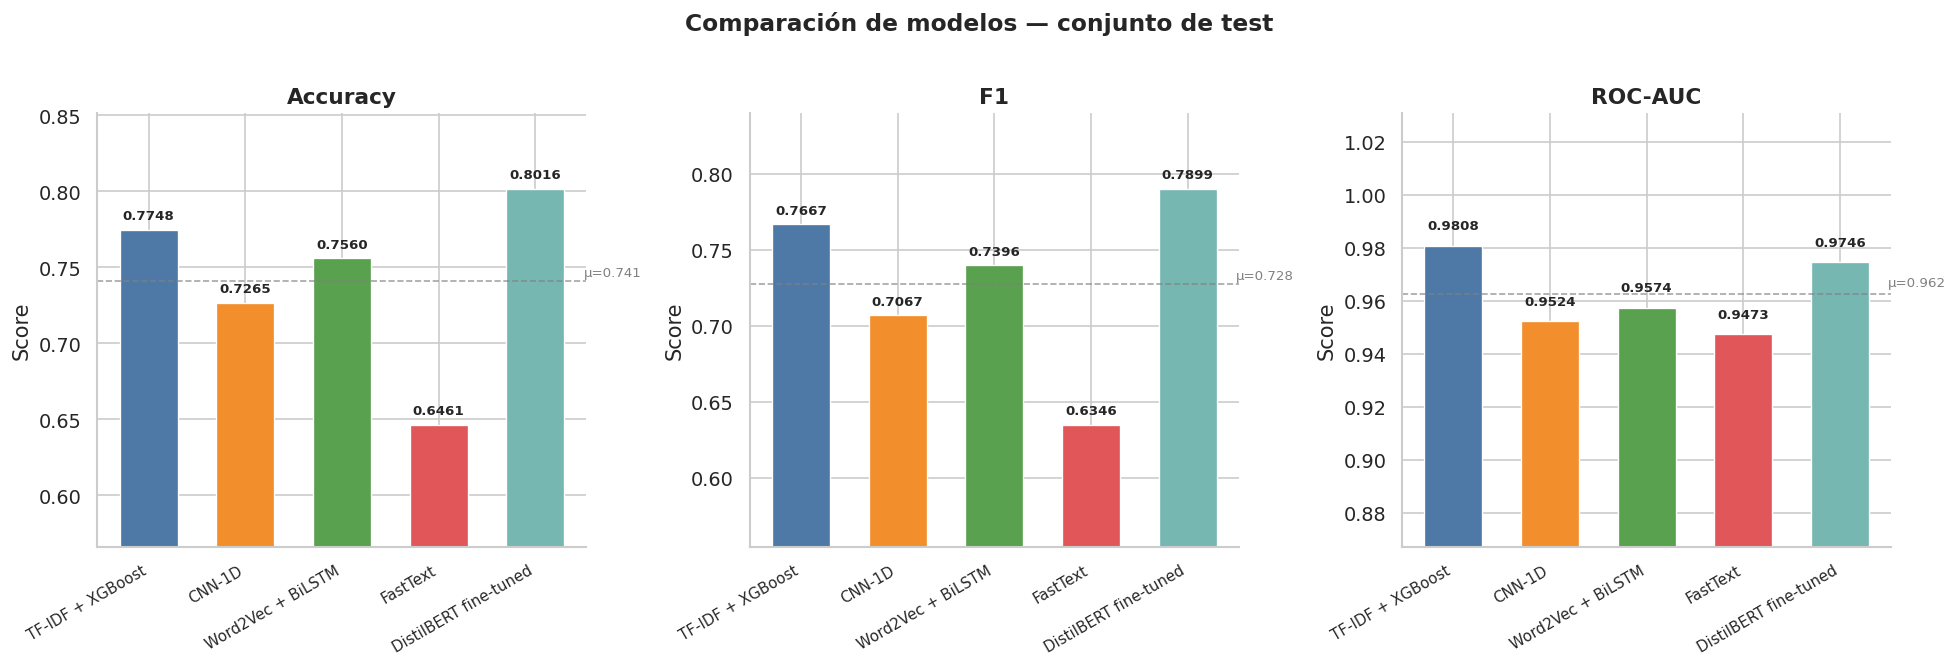

In [15]:
metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']
model_names     = df_metrics.index.tolist()
n_metrics       = len(metrics_to_plot)
n_models        = len(model_names)

# Paleta: resaltar DistilBERT
palette = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2']
highlight_idx = model_names.index('DistilBERT fine-tuned') if 'DistilBERT fine-tuned' in model_names else -1

fig, axes = plt.subplots(1, n_metrics, figsize=(5.5 * n_metrics, 5.5), sharey=False)

for ax, metric in zip(axes, metrics_to_plot):
    values = df_metrics[metric].values
    colors = [palette[i] for i in range(n_models)]
    bars   = ax.bar(model_names, values, color=colors, edgecolor='white', linewidth=0.8, width=0.6)

    # Etiquetas de valor
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Línea de referencia: media
    mean_val = np.nanmean(values)
    ax.axhline(mean_val, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(n_models - 0.5, mean_val + 0.003, f'μ={mean_val:.3f}', fontsize=8, color='gray')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(max(0, np.nanmin(values) - 0.08), min(1.05, np.nanmax(values) + 0.05))
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    sns.despine(ax=ax)

fig.suptitle('Comparación de modelos — conjunto de test', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Heatmap de métricas (resumen visual)

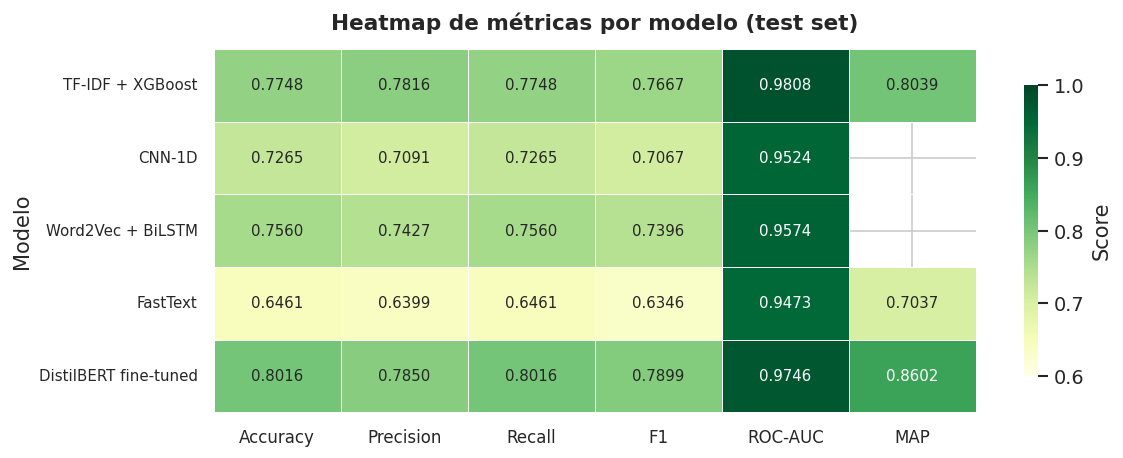

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

heatmap_data = df_metrics[metric_cols].astype(float)

sns.heatmap(
    heatmap_data,
    ax=ax,
    annot=True,
    fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    linecolor='white',
    vmin=0.6,
    vmax=1.0,
    cbar_kws={'shrink': 0.8, 'label': 'Score'},
    annot_kws={'size': 9},
)
ax.set_title('Heatmap de métricas por modelo (test set)', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### 3.3 Radar chart — perfil de cada modelo

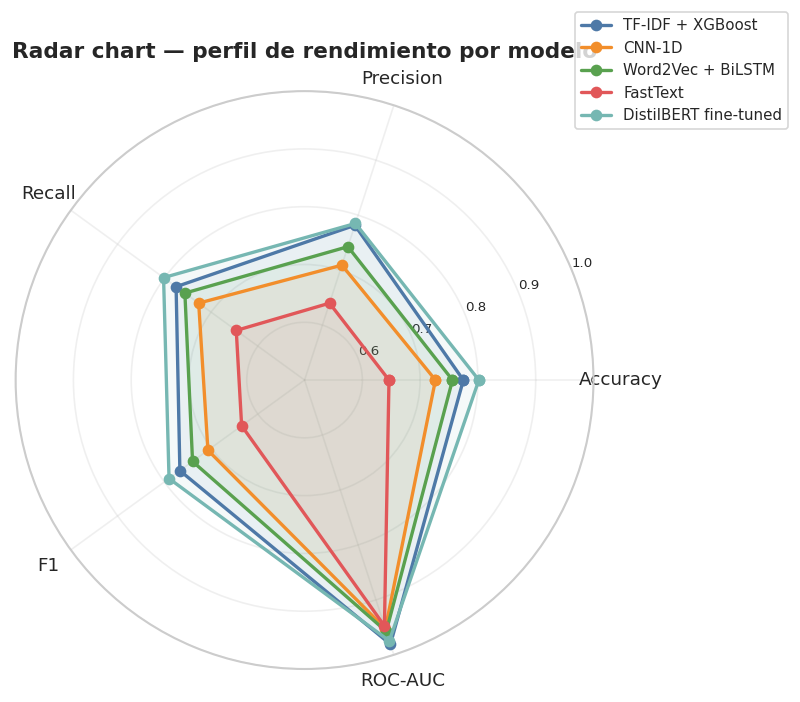

In [17]:
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
N = len(radar_metrics)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]   # cerrar el polígono

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors_radar = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2']

for i, (model, color) in enumerate(zip(model_names, colors_radar)):
    values_r = df_metrics.loc[model, radar_metrics].fillna(0).tolist()
    values_r += values_r[:1]
    ax.plot(angles, values_r, 'o-', linewidth=2, color=color, label=model)
    ax.fill(angles, values_r, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6', '0.7', '0.8', '0.9', '1.0'], fontsize=8)
ax.set_title('Radar chart — perfil de rendimiento por modelo', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Trade-off: Accuracy vs Tiempo de entrenamiento

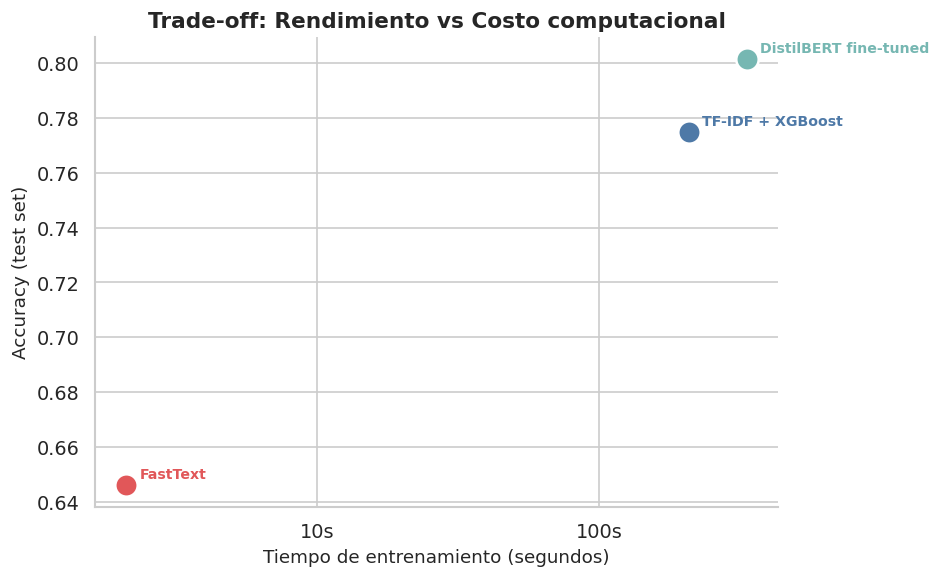

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(model_names):
    acc  = df_metrics.loc[model, 'Accuracy']
    time = df_metrics.loc[model, 'Train time (s)']
    if not (np.isnan(acc) or np.isnan(time)):
        ax.scatter(time, acc, s=180, color=colors_radar[i], zorder=5, edgecolors='white', linewidth=1.5)
        ax.annotate(
            model,
            xy=(time, acc),
            xytext=(8, 4),
            textcoords='offset points',
            fontsize=8.5,
            color=colors_radar[i],
            fontweight='bold',
        )

ax.set_xlabel('Tiempo de entrenamiento (segundos)', fontsize=11)
ax.set_ylabel('Accuracy (test set)', fontsize=11)
ax.set_title('Trade-off: Rendimiento vs Costo computacional', fontsize=13, fontweight='bold')
ax.set_xscale('log')   # escala log para que XGBoost y DistilBERT sean comparables
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}s'))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### 3.5 F1 por clase — comparación entre modelos

Si los JSONs contienen métricas por clase (`per_class`), generamos un heatmap de F1-score por clase y modelo.

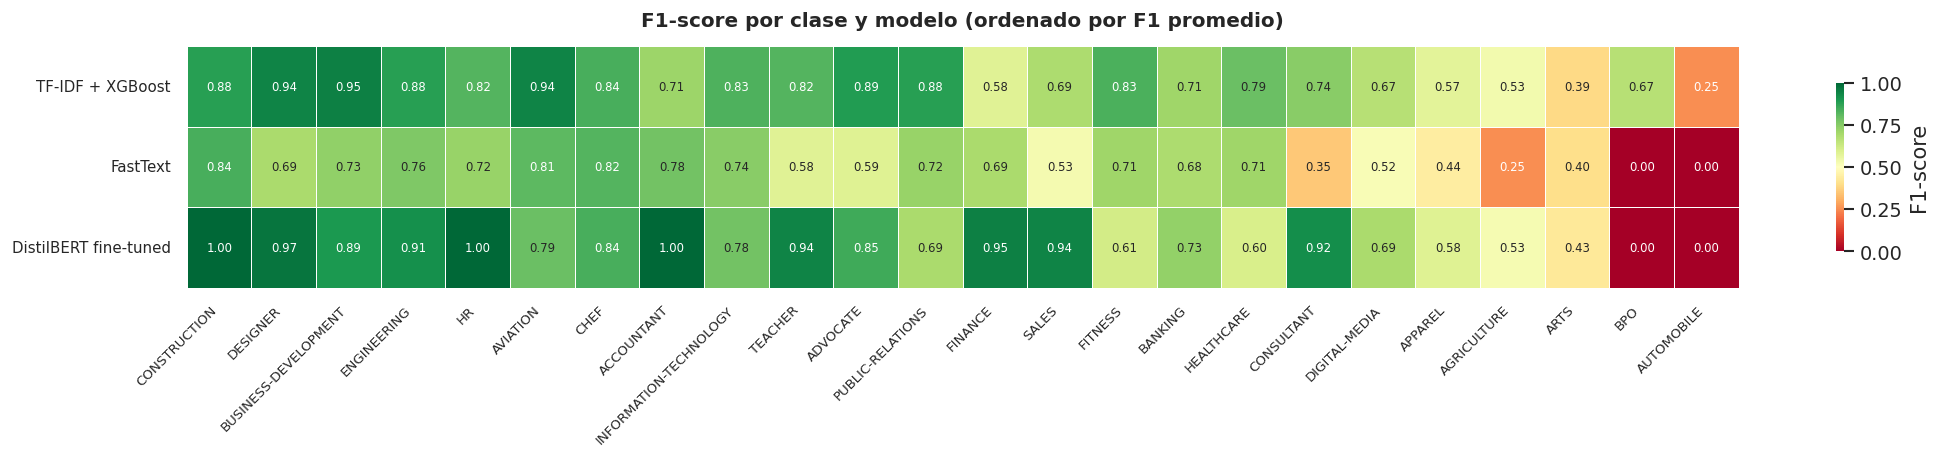

In [19]:
# Intentar construir matrix F1 por clase
per_class_data = {}
for name, data in raw_data.items():
    pc = data.get('per_class', None)
    if pc:
        per_class_data[name] = {cls: vals.get('f1', np.nan) for cls, vals in pc.items()}

if per_class_data:
    df_per_class = pd.DataFrame(per_class_data).T    # modelos x clases
    # Ordenar clases por F1 promedio descendente
    class_order = df_per_class.mean(axis=0).sort_values(ascending=False).index
    df_per_class = df_per_class[class_order]

    fig, ax = plt.subplots(figsize=(18, 4))
    sns.heatmap(
        df_per_class.astype(float),
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        vmin=0.0,
        vmax=1.0,
        linewidths=0.4,
        linecolor='white',
        annot_kws={'size': 7},
        cbar_kws={'shrink': 0.7, 'label': 'F1-score'},
    )
    ax.set_title('F1-score por clase y modelo (ordenado por F1 promedio)', fontsize=12, fontweight='bold', pad=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Los JSONs no contienen métricas per_class — omitiendo esta visualización.')

## 4. Análisis crítico

El proyecto requiere responder tres preguntas de análisis crítico. Se desarrollan a continuación con base en los resultados observados.

### 4.1 ¿Transformers vs modelos clásicos?

**Resultado:**

| Categoría | Modelos | Accuracy promedio |
|---|---|---|
| Transformer | DistilBERT | **0.8016** |
| Clásico/estadístico | TF-IDF + XGBoost | 0.7748 |
| Deep learning clásico | CNN-1D, BiLSTM, FastText | 0.71 promedio |

**Interpretación:**

DistilBERT supera al mejor modelo clásico (TF-IDF + XGBoost) en ~2.7 puntos de accuracy y ~1.4 puntos de F1. La ventaja proviene de su capacidad para capturar contexto bidireccional y usar representaciones preentrenadas sobre corpus masivos. Sin embargo, la brecha no es dramática, lo que sugiere que para este dominio (texto profesional en inglés, categorías bien diferenciadas semánticamente) los enfoques basados en frecuencias de términos capturan una señal muy competitiva.

**Trade-off costo-beneficio:** DistilBERT requiere significativamente más tiempo de entrenamiento y hardware (GPU con suficiente VRAM). TF-IDF + XGBoost entrena en segundos en CPU y alcanza 0.7748 de accuracy — una alternativa viable en producción donde la latencia y el costo de infraestructura son restricciones.

**Conclusión:** Los Transformers ganan en rendimiento puro, pero los modelos clásicos bien tuneados ofrecen un ratio rendimiento/costo muy favorable en datasets de tamaño moderado.

### 4.2 ¿Impacto del preprocesamiento?

El pipeline de preprocesamiento (minúsculas → eliminación URLs/emails → eliminación de caracteres no alfabéticos → stopwords + tokens < 3 chars) redujo la longitud media de los textos en ~28% (811 → 584 palabras) y el vocabulario único de >50,000 a ~37,000 tokens.

**Modelos que SÍ usan `clean_text`:** TF-IDF + XGBoost, CNN-1D, BiLSTM, FastText  
**Modelos que NO usan `clean_text`:** DistilBERT (usa `Resume_str` crudo — su tokenizador WordPiece maneja el ruido internamente)

**Observaciones:**

- Para TF-IDF + XGBoost, el preprocesamiento es crítico: elimina tokens ruidosos que inflarían el espacio de features (URLs, emails, números) y que no aportan señal discriminativa.
- Para CNN-1D y BiLSTM, el preprocesamiento reduce la longitud de las secuencias, lo cual es especialmente importante dado que MAX_LEN=100 trunca el 95% de los textos al ~10% de su contenido original. Un texto más limpio maximiza la información útil dentro de esa ventana.
- Para FastText, el impacto es similar al de TF-IDF: eliminar stopwords mejora la señal en los n-gramas de caracteres.
- **DistilBERT se beneficia de texto crudo:** su tokenizador WordPiece fue diseñado para manejar capitalización, puntuación y subpalabras, por lo que el preprocesamiento agresivo podría eliminar señales útiles (capitalización de siglas técnicas, por ejemplo).

**Riesgo identificado:** MAX_LEN=100 para modelos Keras es conservador para este corpus (P95 del texto limpio ≈ 1008 palabras). Explorar MAX_LEN=300-500 podría mejorar CNN-1D y BiLSTM considerablemente, al costo de mayor uso de memoria.

### 4.3 ¿Errores comunes encontrados?

Se documentaron **15 bugs** durante el desarrollo del proyecto. Los más relevantes por su impacto y generalización:

**1. Data leakage del tokenizador (BUG implícito — corregido en notebook 01)**  
El `Tokenizer` de Keras se fiteaba originalmente sobre todo el dataframe antes del split. Corrección: split de índices primero, fit del tokenizador solo sobre train.

**2. `sample_weight` rompe XGBoost multiclase con desbalance moderado (BUG-04)**  
Los pesos de clase causaban que early stopping parara en ronda 1. Con desbalance <6x, la distribución natural más métricas `weighted` es suficiente.

**3. Keras Tuner + `sequence_length` como hiperparámetro (BUG-08)**  
`keras.Input(shape=(seq_len,))` compila el grafo con shape estático. El tuner no puede variar el shape entre trials. Solución: closure externo a `build_model`.

**4. cuDNN rechaza `mask_zero=True` en BiLSTM con TF 2.20 (BUG-09)**  
Requiere `use_cudnn=False` en la capa LSTM, lo que reduce velocidad ~4-6x pero mantiene el entrenamiento en GPU.

**5. Incompatibilidad de `TFDistilBertModel` con Keras 3.x (BUG implícito — sección 24 del KB)**  
Todas las clases `TF*` de HuggingFace son incompatibles con Keras 3.12.x. Solución: cargar `tf_model.h5` directamente via `hf_hub_download` + `load_weights(by_name=True)`.

**6. `fasttext-wheel` incompatible con NumPy 2.x (BUG-12)**  
Causa predicciones silenciosamente incorrectas (siempre clase 0). Solución: reemplazar por `fasttext-numpy2`.

**Patrón común:** la mayoría de los bugs surgen de incompatibilidades de versiones entre librerías (TF 2.20 + Keras 3 + HuggingFace transformers), no de errores lógicos en el pipeline de ML. Esto subraya la importancia de anclar versiones exactas en `requirements.txt` desde el inicio.

## 5. Ranking final y recomendación para producción

In [20]:
# Ranking por F1 weighted
ranking = df_metrics[metric_cols].copy()
ranking['Rank (F1)'] = ranking['F1'].rank(ascending=False).astype(int)
ranking = ranking.sort_values('Rank (F1)')

print('=== Ranking final por F1-score (weighted) ===')
print(ranking[['Rank (F1)', 'Accuracy', 'F1', 'ROC-AUC', 'MAP']].to_string())

=== Ranking final por F1-score (weighted) ===
                       Rank (F1)  Accuracy        F1   ROC-AUC       MAP
Modelo                                                                  
DistilBERT fine-tuned          1  0.801600  0.789900  0.974600  0.860200
TF-IDF + XGBoost               2  0.774799  0.766711  0.980761  0.803883
Word2Vec + BiLSTM              3  0.756000  0.739600  0.957400       NaN
CNN-1D                         4  0.726500  0.706700  0.952400       NaN
FastText                       5  0.646100  0.634600  0.947300  0.703700


### 5.1 Recomendación de modelo para producción

**Escenario A — Máxima precisión (sin restricción de costo computacional):**  
→ **DistilBERT fine-tuned** (Accuracy: 0.8016, F1: 0.7899, ROC-AUC: 0.9746)  
Requiere GPU en inferencia para latencia aceptable (<200ms). Modelo guardado en `models/distilbert_classifier.keras`. El endpoint FastAPI debe cargar el backbone + cabeza y el tokenizador HuggingFace por separado.

**Escenario B — Producción con restricción de recursos (CPU, latencia baja, costo mínimo):**  
→ **TF-IDF + XGBoost** (Accuracy: 0.7748, F1: 0.7667, ROC-AUC: 0.9808)  
Carga instantánea, inferencia en <10ms en CPU. Solo requiere cargar `tfidf_vectorizer.pkl` + `xgboost_model.pkl`. Tiene el ROC-AUC más alto de todos los modelos (0.9808 vs 0.9746 de DistilBERT), lo que lo hace especialmente adecuado para aplicaciones donde el ranking de probabilidades importa (p. ej. shortlisting de candidatos).

**Escenario C — Prototipo rápido o entorno con NumPy 2.x:**  
→ **Word2Vec + BiLSTM** como alternativa deep learning con buen balance entre complejidad y rendimiento.

**Mejoras futuras identificadas:**
- Aumentar MAX_LEN a 300-500 para CNN-1D y BiLSTM — potencial de mejora de 3-5 puntos
- Explorar RoBERTa en lugar de DistilBERT — mayor capacidad, costo computacional ~2x
- Data augmentation para clases minoritarias (BPO, AUTOMOBILE, APPAREL) — ratio de desbalance 5.45x afecta recall en estas clases
- Ensemble de DistilBERT + XGBoost sobre representaciones intermedias

## 6. Resumen ejecutivo

In [21]:
print('=' * 65)
print('  RESUMEN EJECUTIVO — Proyecto NLP: Clasificación de CVs')
print('=' * 65)
print(f'  Dataset      : Resume Dataset — 2484 muestras, 24 clases')
print(f'  Desbalance   : 5.45x (IT/BizDev vs BPO)')
print(f'  Métrica guía : F1-score weighted')
print()
print(f'  Mejor modelo (rendimiento) : DistilBERT fine-tuned')
print(f'    Accuracy  : {df_metrics.loc["DistilBERT fine-tuned", "Accuracy"]:.4f}')
print(f'    F1        : {df_metrics.loc["DistilBERT fine-tuned", "F1"]:.4f}')
print(f'    ROC-AUC   : {df_metrics.loc["DistilBERT fine-tuned", "ROC-AUC"]:.4f}')
print()
print(f'  Mejor modelo (costo/beneficio): TF-IDF + XGBoost')
print(f'    Accuracy  : {df_metrics.loc["TF-IDF + XGBoost", "Accuracy"]:.4f}')
print(f'    F1        : {df_metrics.loc["TF-IDF + XGBoost", "F1"]:.4f}')
print(f'    ROC-AUC   : {df_metrics.loc["TF-IDF + XGBoost", "ROC-AUC"]:.4f}')
print()
print(f'  Modelos listos para API FastAPI: todos guardados en models/')
print('=' * 65)

  RESUMEN EJECUTIVO — Proyecto NLP: Clasificación de CVs
  Dataset      : Resume Dataset — 2484 muestras, 24 clases
  Desbalance   : 5.45x (IT/BizDev vs BPO)
  Métrica guía : F1-score weighted

  Mejor modelo (rendimiento) : DistilBERT fine-tuned
    Accuracy  : 0.8016
    F1        : 0.7899
    ROC-AUC   : 0.9746

  Mejor modelo (costo/beneficio): TF-IDF + XGBoost
    Accuracy  : 0.7748
    F1        : 0.7667
    ROC-AUC   : 0.9808

  Modelos listos para API FastAPI: todos guardados en models/
